<a href="https://colab.research.google.com/github/zkoymen/yolo26-cnn-architecture-lab/blob/main/experiments/01_yolov26_inspection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q -U ultralytics

import torch
import ultralytics

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 11.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics: 8.4.165
PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA L4



image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 11.8ms
Speed: 105.9ms preprocess, 11.8ms inference, 38.2ms postprocess per image at shape (1, 3, 640, 480)


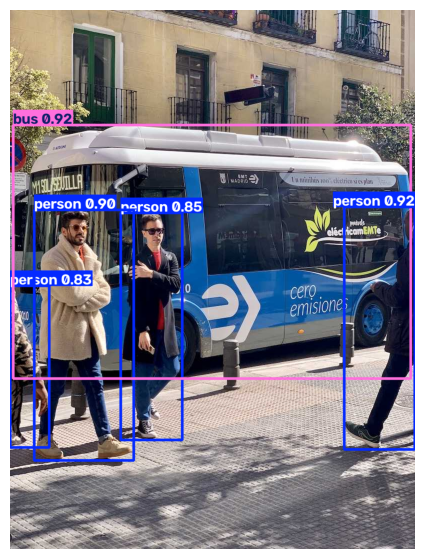

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("yolo26s.pt")

results = model(
    "https://ultralytics.com/images/bus.jpg",
    imgsz=640,
    device=0
)

img = results[0].plot()

plt.figure(figsize=(10, 7))
plt.imshow(img[..., ::-1])
plt.axis("off")
plt.show()

In [ ]:
net = model.model

print("\nMODEL LAYERS\n")

for i, layer in enumerate(net.model):
    params = sum(p.numel() for p in layer.parameters())

    print(
        f"{i:02d} | "
        f"{layer.__class__.__name__:15s} | "
        f"from={str(getattr(layer, 'f', '?')):10s} | "
        f"params={params:,}"
    )


MODEL LAYERS

00 | Conv            | from=-1         | params=928
01 | Conv            | from=-1         | params=18,560
02 | C3k2            | from=-1         | params=26,080
03 | Conv            | from=-1         | params=147,712
04 | C3k2            | from=-1         | params=103,360
05 | Conv            | from=-1         | params=590,336
06 | C3k2            | from=-1         | params=346,112
07 | Conv            | from=-1         | params=1,180,672
08 | C3k2            | from=-1         | params=1,380,352
09 | SPPF            | from=-1         | params=656,896
10 | C2PSA           | from=-1         | params=990,976
11 | Upsample        | from=-1         | params=0
12 | Concat          | from=[-1, 6]    | params=0
13 | C3k2            | from=-1         | params=477,184
14 | Upsample        | from=-1         | params=0
15 | Concat          | from=[-1, 4]    | params=0
16 | C3k2            | from=-1         | params=136,192
17 | Conv            | from=-1         | params=147,712
18 

In [ ]:
import torch
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("bus.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (640, 640))

x = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
x = x.unsqueeze(0).to(next(net.parameters()).device)


layers_to_watch = [0, 2, 4, 6, 8]

activations = {}
hooks = []

def make_hook(idx):
    def hook(module, input, output):
        activations[idx] = output.detach().cpu()
    return hook

for idx in layers_to_watch:
    hooks.append(net.model[idx].register_forward_hook(make_hook(idx)))

net.eval()

with torch.no_grad():
    _ = net(x)

for h in hooks:
    h.remove()


#tensor shapes here
for idx in layers_to_watch:
    a = activations[idx]
    print(
        f"Layer {idx:02d} | "
        f"{net.model[idx].__class__.__name__:6s} | "
        f"shape = {tuple(a.shape)}"
    )

Layer 00 | Conv   | shape = (1, 32, 320, 320)
Layer 02 | C3k2   | shape = (1, 128, 160, 160)
Layer 04 | C3k2   | shape = (1, 256, 80, 80)
Layer 06 | C3k2   | shape = (1, 256, 40, 40)
Layer 08 | C3k2   | shape = (1, 512, 20, 20)


Feature tensor: torch.Size([128, 160, 160])


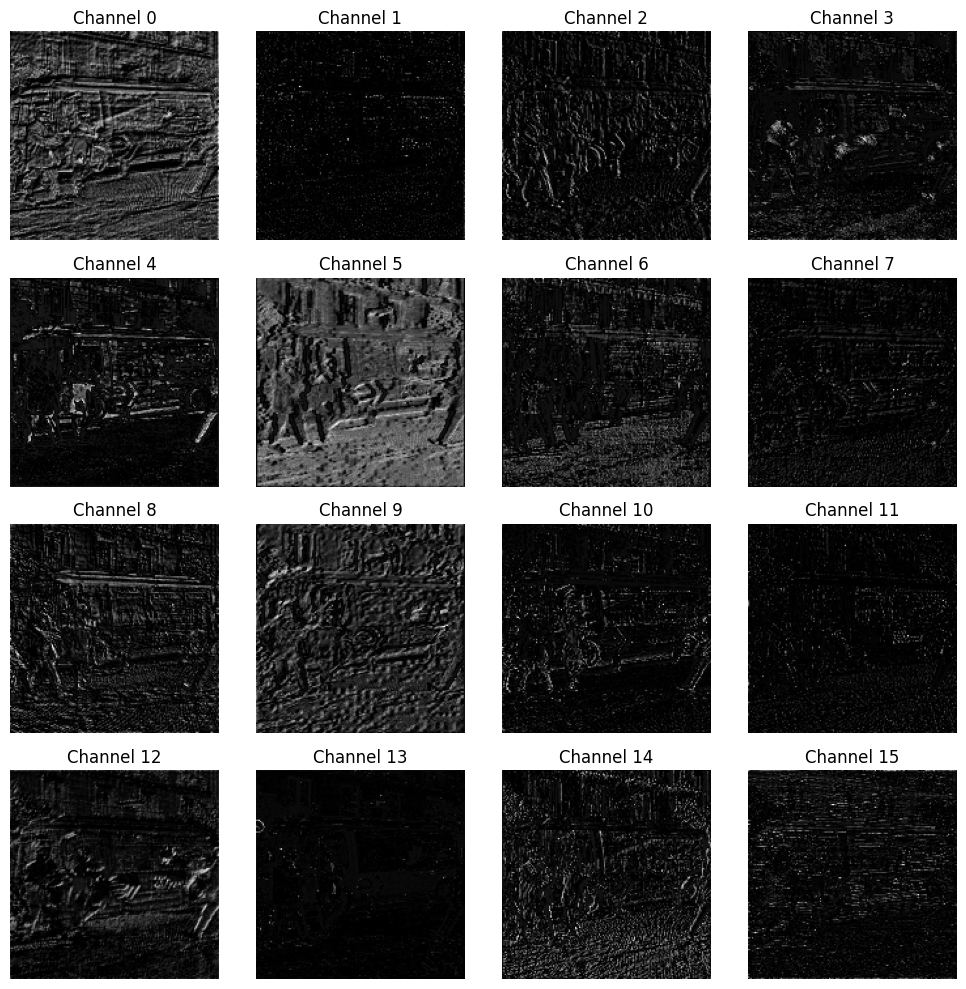

In [ ]:
import matplotlib.pyplot as plt

layer_idx = 2
feat = activations[layer_idx][0]

# with each layer the feature channel size doubles and the map resolution gots in half due to
# increased abstraction in the features in the latest layers


print("Feature tensor:", feat.shape)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    fmap = feat[i]

    ax.imshow(fmap, cmap="gray")
    ax.set_title(f"Channel {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()